# 🚀 Model Deployment – Predict Immunotherapy Response
## Hackathon DIGPHAT – PharmacogenomicDay

In this notebook you will:
1. **Load** the trained model and preprocessing artifacts saved from the Development Notebook
2. **Load** the held-out test data (unseen during training)
3. **Apply** the exact same preprocessing pipeline
4. **Generate** predictions (probabilities + binary labels)
5. **Submit** your predictions via Google Form for evaluation

In [1]:
import pandas as pd
import numpy as np
import os, joblib, warnings, requests
warnings.filterwarnings('ignore')

print("Imports OK ✅")

Imports OK ✅


---
# 1. Load Model & Preprocessing Artifacts

All fitted objects (model, scalers, feature selector, encoders, imputer) were saved
in the Development Notebook. We load them here to ensure the **exact same**
transformations are applied to the test data.

In [3]:
# ── Load saved artifacts ──────────────────────────────────────────────────────
artifacts = joblib.load('artifacts/pipeline_artifacts.joblib')

# Fitted Pipeline (ADASYN + SelectKBest + LogisticRegression)
pipeline          = artifacts['pipeline']
model_name        = artifacts['model_name']

# PCA (fitted on training transcriptomics)
pca               = artifacts['pca']
pca_columns       = artifacts['pca_columns']

# Scalers
trans_scaler      = artifacts['trans_scaler']       # StandardScaler – transcriptomic
pathway_scaler    = artifacts['pathway_scaler']     # StandardScaler – ssGSEA pathways
clr_scaler        = artifacts['clr_scaler']         # StandardScaler – CLR deconvolution

# Feature lists
keep_genes        = artifacts['keep_genes']         # variance-filtered genes
cell_cols         = artifacts['cell_cols']           # deconvolution cell-type columns
feature_columns   = artifacts['feature_columns']    # expected column order

# Clinical encoding
encoders          = artifacts['encoders']           # dict of fitted encoders
dummy_cols        = artifacts['dummy_cols']          # ['Arm']
binary_cols       = artifacts['binary_cols']
ordinal_cols      = artifacts['ordinal_cols']
num_cols          = artifacts['num_cols']            # ['Age']

# Imputation
mice_kernel       = artifacts['mice_kernel']         # fitted MICE kernel

print(f'✅ Loaded pipeline: {model_name}')
print(f'   PCA components: {len(pca_columns)}')
print(f'   Expected feature columns: {len(feature_columns)}')
print(f'   Artifact keys: {list(artifacts.keys())}')


✅ Loaded pipeline: ADASYN + SelectKBest + LogisticRegression
   PCA components: 196
   Expected feature columns: 277
   Artifact keys: ['pipeline', 'model_name', 'pca', 'pca_columns', 'keep_genes', 'trans_scaler', 'pathway_scaler', 'cell_cols', 'clr_scaler', 'encoders', 'dummy_cols', 'binary_cols', 'ordinal_cols', 'num_cols', 'mice_kernel', 'feature_columns']


---
# 2. Load External Test Data

The test data is provided per modality in `Data/test/`.
**No labels are provided** — this is a blind evaluation.

In [4]:
# ── Load test modalities ──────────────────────────────────────────────────────
test_clin = pd.read_csv('Data/test/clinical.csv')
test_dec  = pd.read_csv('Data/test/cell_deconvolution.csv')
test_ssg  = pd.read_csv('Data/test/ssgsea.csv')

print("Loading transcriptomic test data (this may take a moment)...")
test_trn  = pd.read_csv('Data/test/transcriptomic.csv')

print(f"\nTest patients: {len(test_clin)}")
for name, df in [('Clinical', test_clin), ('Deconv', test_dec),
                 ('ssGSEA', test_ssg), ('Transcriptomic', test_trn)]:
    print(f"  {name:15s} → {df.shape}")

Loading transcriptomic test data (this may take a moment)...

Test patients: 57
  Clinical        → (57, 10)
  Deconv          → (57, 27)
  ssGSEA          → (57, 51)
  Transcriptomic  → (57, 40935)


---
# 3. Apply Stored Preprocessing Pipeline

We reproduce the **exact same** steps from the Development Notebook,
using the **fitted** scalers, encoders, PCA, and pipeline stored in the artifacts.

| Step | Modality | Transform |
|------|----------|-----------|
| 3.1 | Transcriptomic | Filter to `keep_genes` → scale → **PCA** |
| 3.2 | ssGSEA Pathways | Scale with fitted `pathway_scaler` |
| 3.3 | Cell Deconvolution | CLR transform → scale with fitted `clr_scaler` |
| 3.4 | Clinical | Encode → MICE impute |
| 3.5 | All | Concatenate & align columns |
| 3.6 | — | Pipeline handles SelectKBest + ADASYN internally |


## 3.1 Transcriptomic Data

In [5]:
# ── 3.1  Transcriptomic preprocessing + PCA ──────────────────────────────────
test_trans = test_trn.drop('Patient_ID', axis=1).copy()

# Keep only the genes that passed variance filtering on training set
# Fill any missing genes with 0 (gene absent in test data)
missing_genes = [g for g in keep_genes if g not in test_trans.columns]
for g in missing_genes:
    test_trans[g] = 0.0
test_trans = test_trans[keep_genes]

# Scale using the fitted StandardScaler from training
test_trans_scaled = pd.DataFrame(
    trans_scaler.transform(test_trans),
    columns=keep_genes
)
print(f'Transcriptomic → {test_trans_scaled.shape[1]} genes (missing filled: {len(missing_genes)})')

# Apply PCA (fitted on training transcriptomics)
test_pca_result = pca.transform(test_trans_scaled)
test_pca_df = pd.DataFrame(
    test_pca_result,
    columns=pca_columns
)
print(f'After PCA → {test_pca_df.shape[1]} principal components')


Transcriptomic → 38030 genes (missing filled: 0)
After PCA → 196 principal components


## 3.2 ssGSEA Pathway Scores

In [6]:
# ── 3.2  Pathway scaling ───────────────────────────────────────────────────────
test_pathway = test_ssg.drop('Patient_ID', axis=1).copy()
test_pathway_scaled = pd.DataFrame(
    pathway_scaler.transform(test_pathway),
    columns=test_pathway.columns
)
print(f"Pathways → {test_pathway_scaled.shape[1]} features")

Pathways → 50 features


## 3.3 Immune Cell Deconvolution (CLR + Scaling)

In [7]:
# ── 3.3  Immune deconvolution: CLR transform + scaling ────────────────────────
test_deconv_raw = test_dec[cell_cols].copy()

# CLR transform (same logic as training)
eps = 1e-6
X_eps = test_deconv_raw + eps
geo_mean = np.exp(np.log(X_eps).mean(axis=1))
clr_values = np.log(X_eps.div(geo_mean, axis=0))

# Scale with the fitted StandardScaler
test_deconv_clr = pd.DataFrame(
    clr_scaler.transform(clr_values),
    columns=cell_cols
)
print(f"Immune deconv → {test_deconv_clr.shape[1]} features")

Immune deconv → 22 features


## 3.4 Clinical Data

Encoding using the **fitted** encoders from training:
- **Categorical** (Arm) → one-hot encoding
- **Binary** (Sex, Sarc, Rhab, Tumor_Sample_Primary_or_Metastasis) → binary encoding
- **Ordinal** (MSKCC, Number_of_Prior_Therapies) → ordinal encoding
- **Numerical** (Age) → standardisation

In [8]:
# ── 3.4  Clinical preprocessing ────────────────────────────────────────────────
# Replace NO_IF with NaN (same as training)
for col in ['Sarc', 'Rhab', 'MSKCC']:
    test_clin[col] = test_clin[col].replace('NO_IF', np.nan)

# Drop Cohort (same as training)
test_clinic = test_clin.drop(columns=['Cohort'], errors='ignore').copy()

# ── 1. One-Hot Encoding for 'Arm' ────────────────────────────────────────────
ohe = encoders['ohe_Arm']
arm_encoded = ohe.transform(test_clinic[dummy_cols])
arm_df = pd.DataFrame(
    arm_encoded,
    columns=ohe.get_feature_names_out(dummy_cols),
    index=test_clinic.index
)

# ── 2. Binary Encoding ───────────────────────────────────────────────────────
binary_encoded = test_clinic[binary_cols].copy()
for col in binary_cols:
    le = encoders[f'le_{col}']
    binary_encoded[col] = le.transform(binary_encoded[col].astype(str))

# ── 3. Ordinal Encoding (MSKCC) ──────────────────────────────────────────────
ordinal_encoded = test_clinic[ordinal_cols].copy()
mskcc_oe = encoders['oe_MSKCC']
ordinal_encoded['MSKCC'] = mskcc_oe.transform(ordinal_encoded[['MSKCC']])

# ── 4. Numerical Scaling (Age) ───────────────────────────────────────────────
age_scaled = test_clinic[num_cols].copy()
scaler_age = encoders['scaler_Age']
age_scaled[num_cols] = scaler_age.transform(age_scaled[num_cols])

# ── Combine all encoded clinical features ─────────────────────────────────────
test_clinical_encoded = pd.concat([
    arm_df,
    binary_encoded,
    ordinal_encoded,
    age_scaled
], axis=1)

print(f"Clinical → {test_clinical_encoded.shape[1]} features")
print(f"  Missing values: {test_clinical_encoded.isna().sum().sum()}")

Clinical → 9 features
  Missing values: 6


### 3.4.1 Handling Missing Values with MICE

We use the **fitted** MICE kernel from the training set to impute missing values
in the test clinical data.

In [9]:
# ── MICE imputation using fitted kernel ────────────────────────────────────────
# The MICE kernel was fitted on training data that included a 'Response' column.
# We add a dummy Response column to match the expected schema,
# then drop it after imputation.

missing_count = test_clinical_encoded.isna().sum().sum()
print(f"Missing values before imputation: {missing_count}")

if missing_count > 0 and mice_kernel is not None:
    # Add dummy Response column at position 0 (same as training)
    test_for_mice = pd.concat([
        pd.DataFrame({'Response': np.zeros(len(test_clinical_encoded), dtype=int)}),
        test_clinical_encoded.reset_index(drop=True)
    ], axis=1)
    
    # Match column dtypes to the kernel's training data
    for col in mice_kernel.working_data.columns:
        if col in test_for_mice.columns:
            test_for_mice[col] = test_for_mice[col].astype(
                mice_kernel.working_data[col].dtype
            )
    
    test_imputed = mice_kernel.impute_new_data(test_for_mice).complete_data()
    
    # Drop the dummy Response column
    test_clinical_imputed = test_imputed.drop(columns=['Response'])
    print(f"After MICE imputation: {test_clinical_imputed.isna().sum().sum()} missing")
elif missing_count > 0:
    test_clinical_imputed = test_clinical_encoded.fillna(test_clinical_encoded.median())
    print("Filled with median (MICE kernel not available)")
else:
    test_clinical_imputed = test_clinical_encoded.copy()
    print("No missing values – no imputation needed")


Missing values before imputation: 6
After MICE imputation: 0 missing


## 3.5 Integrate All Preprocessed Features

Combine clinical (imputed), PCA-reduced transcriptomics, pathway scores, and
deconvolution features into a single test matrix.
The column order is aligned to match the training data exactly.


In [10]:
# ── 3.5  Combine all modalities ────────────────────────────────────────────────
X_test_all = pd.concat([
    test_clinical_imputed.reset_index(drop=True),
    test_pca_df.reset_index(drop=True),           # PCA instead of raw transcriptomics
    test_pathway_scaled.reset_index(drop=True),
    test_deconv_clr.reset_index(drop=True),
], axis=1)

# Align columns to match training feature order
# (fill any missing columns with 0, drop any extra columns)
for col in feature_columns:
    if col not in X_test_all.columns:
        X_test_all[col] = 0.0
X_test_final = X_test_all[feature_columns]

print(f'Combined test feature matrix: {X_test_final.shape}')
print(f'Columns match training: {list(X_test_final.columns) == feature_columns}')


Combined test feature matrix: (57, 277)
Columns match training: True


## 3.6 Feature Selection & Sampling

Feature selection (SelectKBest with mutual information) and data sampling
(ADASYN) are now embedded **inside the pipeline**.
No manual feature-selection step is needed — the pipeline handles it
automatically when calling `pipeline.predict()`.


In [11]:
# Feature selection (SelectKBest) and sampling (ADASYN) are inside the pipeline.
# No manual step needed. The pipeline will handle this automatically.
print(f'Test feature matrix ready: {X_test_final.shape}')
print(f'Pipeline steps: {[step[0] for step in pipeline.steps]}')

Test feature matrix ready: (57, 277)
Pipeline steps: ['sampler', 'feature selector', 'classifier']


---
# 4. Generate Predictions

In [12]:
# ── Predict ───────────────────────────────────────────────────────────────────
# The pipeline internally applies SelectKBest and then LogisticRegression.
# Note: ADASYN (sampler) is automatically skipped during prediction.
y_pred = pipeline.predict(X_test_final)

if hasattr(pipeline, 'predict_proba'):
    y_proba = pipeline.predict_proba(X_test_final)[:, 1]
else:
    y_proba = pipeline.decision_function(X_test_final)

predictions_df = pd.DataFrame({
    'Patient_ID': test_clin['Patient_ID'].values,
    'Predicted_Response': y_pred,
    'Probability': np.round(y_proba, 4)
})
display(predictions_df)

print(f'\nPredicted Responders:     {int(y_pred.sum())} / {len(y_pred)}')
print(f'Predicted Non-Responders: {int((1 - y_pred).sum())} / {len(y_pred)}')


,Patient_ID,Predicted_Response,Probability
0,G138701_RCCBMS-00097-T_v1_RNA_OnPrem,1,0.5080
1,G138701_RCCBMS-00099-T_v1_RNA_OnPrem,0,0.2321
2,G138701_RCCBMS-00093-T_v1_RNA_OnPrem,0,0.0616
3,G138701_RCCBMS-00072-T_v1_RNA_OnPrem,0,0.3943
4,G138701_RCCBMS-00125-T_v1_RNA_OnPrem,0,0.4662
5,G138701_RCCBMS-00165-T_v1_RNA_OnPrem,1,0.6446
6,G138701_RCCBMS-00169-T_v1_RNA_OnPrem,1,0.5005
7,P66425-08E-Run1_S6_L001,0,0.1587
8,P66291-12D-Run1_S29_L002,0,0.3789
9,P66451-09H-Run1_S2_L001,1,0.5011



Predicted Responders:     14 / 57
Predicted Non-Responders: 43 / 57


---
# 5. Performance Report (when labels become available)

Once the instructor releases the true labels, you can evaluate your model
using the cell below.

=== Performance Report ===
ROC AUC:  0.519
PR AUC:   0.183
MCC:      0.088

              precision    recall  f1-score   support

    Non-Resp       0.86      0.77      0.81        48
   Responder       0.21      0.33      0.26         9

    accuracy                           0.70        57
   macro avg       0.54      0.55      0.54        57
weighted avg       0.76      0.70      0.73        57



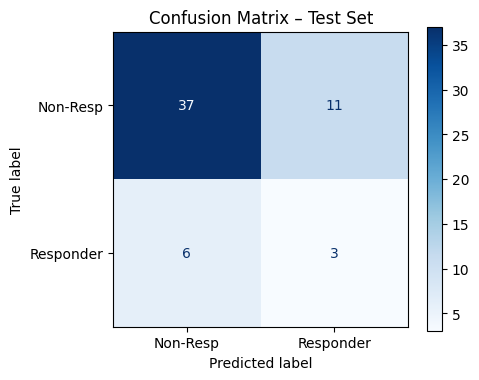

In [13]:
# ── Uncomment when true labels are available ──────────────────────────────────
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             matthews_corrcoef, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
import matplotlib.pyplot as plt

y_true = np.load('Data/test/y_test.npy')

print("=== Performance Report ===")
print(f"ROC AUC:  {roc_auc_score(y_true, y_proba):.3f}")
print(f"PR AUC:   {average_precision_score(y_true, y_proba):.3f}")
print(f"MCC:      {matthews_corrcoef(y_true, y_pred):.3f}")
print()
print(classification_report(y_true, y_pred, target_names=['Non-Resp','Responder']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax,
    display_labels=['Non-Resp', 'Responder'], cmap='Blues')
ax.set_title('Confusion Matrix – Test Set')
plt.tight_layout(); plt.show()

---
# 6. Submit Predictions via Google Form

Push your team's predictions directly from this notebook.
No need to open the form manually — the code below sends an HTTP POST request
with your team name and predicted labels.

> ⚠️ **Replace the placeholders** below with the actual Google Form URL
> and entry IDs provided by the instructor.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# ▶  FILL IN THESE VALUES (provided by your instructor)
# ══════════════════════════════════════════════════════════════════════════════
TEAM_NAME      = "YOUR_TEAM_NAME"       # ← change this
FORM_URL       = "https://docs.google.com/forms/d/e/YOUR_FORM_ID/formResponse"
ENTRY_TEAM     = "entry.XXXXXXXXX"       # ← entry ID for Team Name field
ENTRY_PREDS    = "entry.YYYYYYYYY"       # ← entry ID for Predictions field
# ══════════════════════════════════════════════════════════════════════════════

# Convert predictions to a comma-separated string
pred_string = ",".join(map(str, y_pred.tolist()))

payload = {
    ENTRY_TEAM:  TEAM_NAME,
    ENTRY_PREDS: pred_string,
}

response = requests.post(FORM_URL, data=payload)

if response.status_code == 200:
    print(f"✅ Predictions submitted successfully!")
    print(f"   Team: {TEAM_NAME}")
    print(f"   Predictions: {pred_string[:80]}...")
else:
    print(f"❌ Submission failed (HTTP {response.status_code})")
    print(f"   Check the form URL and entry IDs.")

---
## 🎉 Congratulations!

You have successfully completed the full ML pipeline:
1. ✅ Trained a model on multi-modal pharmacogenomic data
2. ✅ Applied the pipeline to unseen test data
3. ✅ Submitted your predictions for evaluation

**Good luck!** 🧬🔬